In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv("C:/Data_Analyst_Journey/Luke Barousse/job_postings_flat.csv")

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

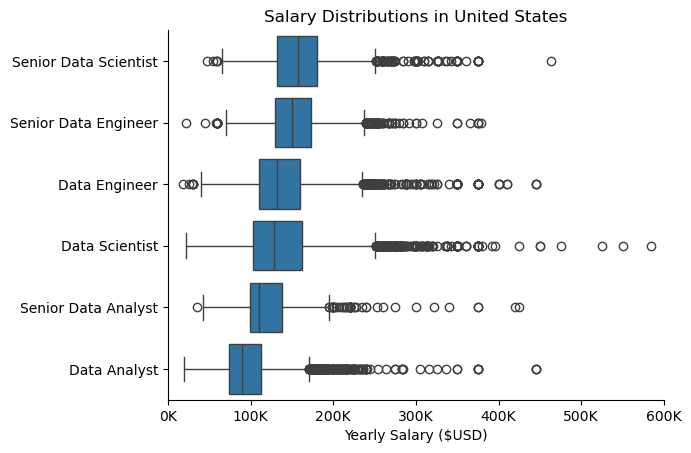

In [2]:
country = 'United States'
df_selected = df[df['job_country']==country].copy().dropna(subset='salary_year_avg')

jobs = df_selected['job_title_short'].value_counts().index[:6]
df_selected = df_selected[df_selected['job_title_short'].isin(jobs)]

jobs_order = df_selected.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

sns.boxplot(df_selected, x='salary_year_avg', y='job_title_short', order=jobs_order)
sns.despine()
plt.xlim(0, 600000)
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
plt.title(f'Salary Distributions in {country}')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))

In [3]:
job = 'Data Analyst'
df_exploded = df_selected[df_selected['job_title_short']==job].explode('job_skills')
df_skills_count_salary = df_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_skills_high_pay = df_skills_count_salary.sort_values(by='median', ascending=False).head(10)
df_skills_high_demand = df_skills_count_salary.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

df_skills_high_pay, df_skills_high_demand

(              count    median
 job_skills                   
 unreal            1  229138.0
 fastapi           1  212500.0
 solidity          1  179000.0
 hugging face      1  175000.0
 blazor            1  161000.0
 apl               2  155000.0
 mxnet             2  149000.0
 zoom             63  145000.0
 graphql          45  141420.0
 notion            4  137500.0,
             count    median
 job_skills                 
 python       3741  100000.0
 oracle        655  100000.0
 tableau      3350   95500.0
 r            2173   95298.5
 sql          5941   95000.0
 power bi     2372   90000.0
 sas          2020   90000.0
 excel        5308   83500.0
 powerpoint    971   82350.0
 word          951   79500.0)

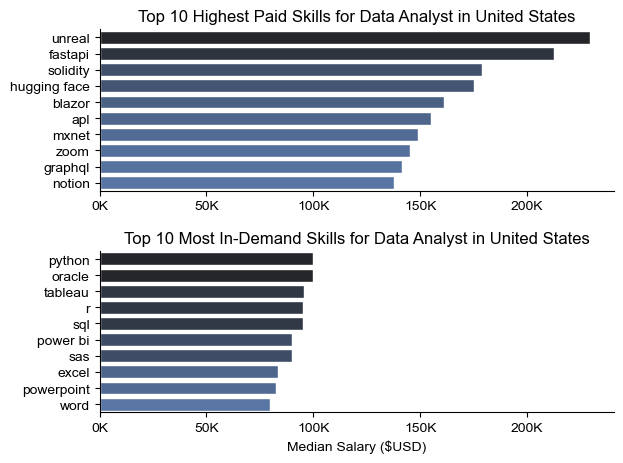

In [4]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style='ticks')
sns.barplot(df_skills_high_pay, x='median', y='job_skills', hue='median', palette='dark:b_r', ax=ax[0], legend=False)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].set_title(f'Top 10 Highest Paid Skills for {job} in {country}')

sns.set_theme(style='ticks')
sns.barplot(df_skills_high_demand, x='median', y='job_skills', hue='median', palette='dark:b_r', ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_title(f'Top 10 Most In-Demand Skills for {job} in {country}')

sns.despine()
plt.tight_layout()